# Data Visualization & Analysis (QeMFi / CM + EV)

This notebook:
- Loads CM features + EV targets.
- Checks basic stats and ranges.
- Visualizes distributions and correlations.
- Runs PCA for structure.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("default")
sns.set_theme(context="notebook", style="whitegrid")

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

data_dir = repo_root / "data" / "QeMFI_all" / "model_training_test_data"

x_path = data_dir / "CM_train.npy"
y_path = data_dir / "EV_train.npy"

x = np.load(x_path)
y = np.load(y_path).reshape(-1)

print("X shape:", x.shape)
print("y shape:", y.shape)

n_features_for_df = min(100, x.shape[1])

df = pd.DataFrame(
    x[:, :n_features_for_df],
    columns=[f"f_{i}" for i in range(n_features_for_df)],
)
df["target"] = y

df.head()


X shape: (6000000, 486)
y shape: (6000000,)


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_91,f_92,f_93,f_94,f_95,f_96,f_97,f_98,f_99,target
0,73.516695,29.116708,24.719788,42.858288,17.158454,19.627502,13.022778,11.380941,9.755522,10.12839,...,17.557013,12.695615,16.97092,14.067855,25.63176,36.858105,12.423901,14.845086,25.753235,22986.3
1,73.516695,29.116708,24.719788,42.858288,17.158454,19.627502,13.022778,11.380941,9.755522,10.12839,...,17.557013,12.695615,16.97092,14.067855,25.63176,36.858105,12.423901,14.845086,25.753235,27703.6
2,73.516695,29.116708,24.719788,42.858288,17.158454,19.627502,13.022778,11.380941,9.755522,10.12839,...,17.557013,12.695615,16.97092,14.067855,25.63176,36.858105,12.423901,14.845086,25.753235,41797.2
3,73.516695,29.116708,24.719788,42.858288,17.158454,19.627502,13.022778,11.380941,9.755522,10.12839,...,17.557013,12.695615,16.97092,14.067855,25.63176,36.858105,12.423901,14.845086,25.753235,51584.9
4,73.516695,29.116708,24.719788,42.858288,17.158454,19.627502,13.022778,11.380941,9.755522,10.12839,...,17.557013,12.695615,16.97092,14.067855,25.63176,36.858105,12.423901,14.845086,25.753235,52789.8


 Basic Feature Stats (first 100 features)


,count,mean,std,min,25%,50%,75%,max
f_0,6000000.0,71.276806,6.335183,53.358707,73.516695,73.516695,73.516695,73.516695
f_1,6000000.0,23.050585,9.633384,7.031254,14.027374,25.394432,28.793933,47.679443
f_2,6000000.0,26.138483,8.509001,7.122654,20.548139,24.693832,31.625061,53.233356
f_3,6000000.0,21.095498,11.199485,7.306014,12.666059,17.528467,24.727965,50.416262
f_4,6000000.0,19.299652,13.266335,1.781771,7.442201,17.244146,34.396306,50.022629
...,...,...,...,...,...,...,...,...
f_96,6000000.0,12.950357,13.951535,0.000000,1.308048,9.080678,16.660558,36.858105
f_97,6000000.0,9.561129,9.505211,0.000000,0.230361,8.103737,15.174986,30.738034
f_98,6000000.0,11.401063,11.350533,0.000000,0.500000,7.262213,23.978792,35.297493
f_99,6000000.0,7.997554,10.177013,0.000000,0.345147,1.878725,14.426510,35.848724


 Target Stats
min: -24900.4
max: 129174.4
mean: 54867.6370140667
std: 15365.505961002138


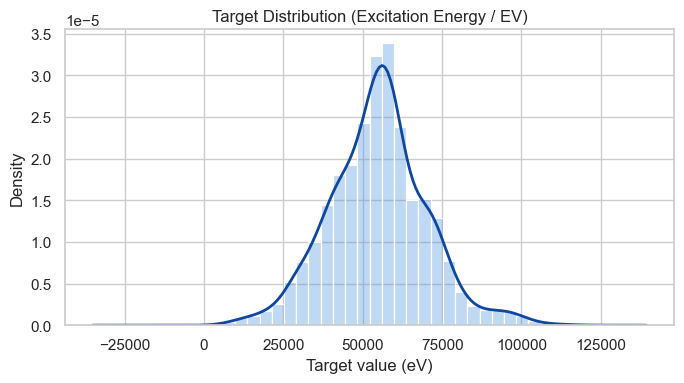

In [3]:
# Basic stats

print(" Basic Feature Stats (first", n_features_for_df, "features)")
display(df.describe().T)

print(" Target Stats")
print("min:", float(y.min()))
print("max:", float(y.max()))
print("mean:", float(y.mean()))
print("std:", float(y.std()))

plt.figure(figsize=(7, 4))

sns.histplot(
    y,
    bins=40,
    stat="density",
    color="#4A90E2",
    alpha=0.35,
    edgecolor=None,
)

sns.kdeplot(
    y,
    color="#0D47A1",
    linewidth=2,
    bw_adjust=5,
)

plt.title("Target Distribution (Excitation Energy / EV)")
plt.xlabel("Target value (eV)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


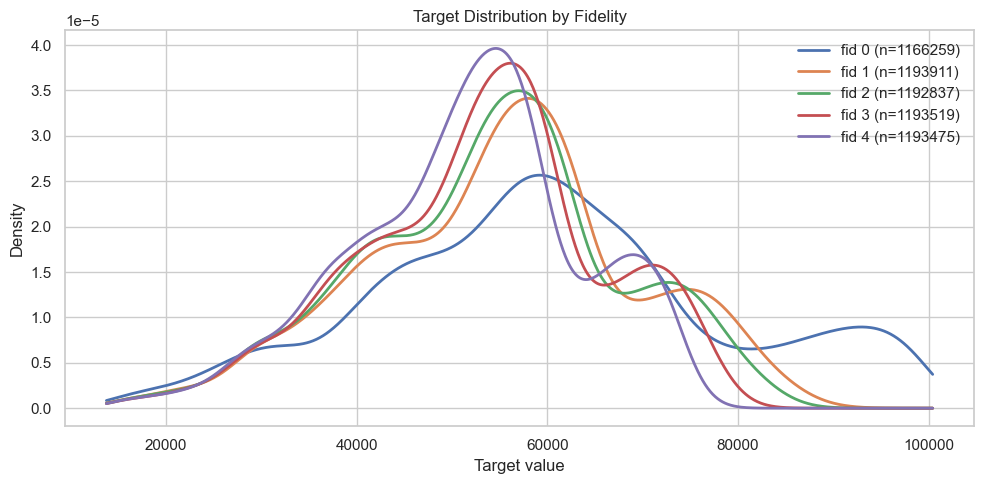

In [4]:
# Target distribution by fidelity
from scipy.stats import gaussian_kde

fid_ids = x[:, -2].astype(int)

lo, hi = np.percentile(y, [0.5, 99.5])
mask = (y >= lo) & (y <= hi)

fid_ids = fid_ids[mask]
y = y[mask]

plt.figure(figsize=(10, 5))

x_grid = np.linspace(y.min(), y.max(), 1000)

for f in range(5):
    y_f = y[fid_ids == f]

    kde = gaussian_kde(y_f, bw_method=0.15)
    plt.plot(
        x_grid,
        kde(x_grid),
        linewidth=2,
        label=f"fid {f} (n={len(y_f)})",
    )

plt.title("Target Distribution by Fidelity")
plt.xlabel("Target value")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


Top 20 features most positively correlated with target:


target    1.000000
f_27      0.425523
f_26      0.371945
f_14      0.296513
f_42      0.257418
f_1       0.256045
f_13      0.252156
f_43      0.251223
f_56      0.227867
f_11      0.220507
f_9       0.219845
f_19      0.218249
f_8       0.213311
f_18      0.211410
f_2       0.179315
f_57      0.143268
f_10      0.138078
f_41      0.125013
f_28      0.102145
f_55      0.092120
Name: target, dtype: float64

 Top 20 features most negatively correlated with target:


f_75   -0.331002
f_33   -0.332853
f_98   -0.336351
f_97   -0.339055
f_23   -0.344165
f_48   -0.353325
f_84   -0.359280
f_49   -0.370439
f_96   -0.376592
f_94   -0.378385
f_93   -0.401018
f_92   -0.405979
f_91   -0.407133
f_50   -0.418948
f_90   -0.419711
f_47   -0.431376
f_6    -0.432335
f_45   -0.432523
f_46   -0.451284
f_7    -0.486371
Name: target, dtype: float64

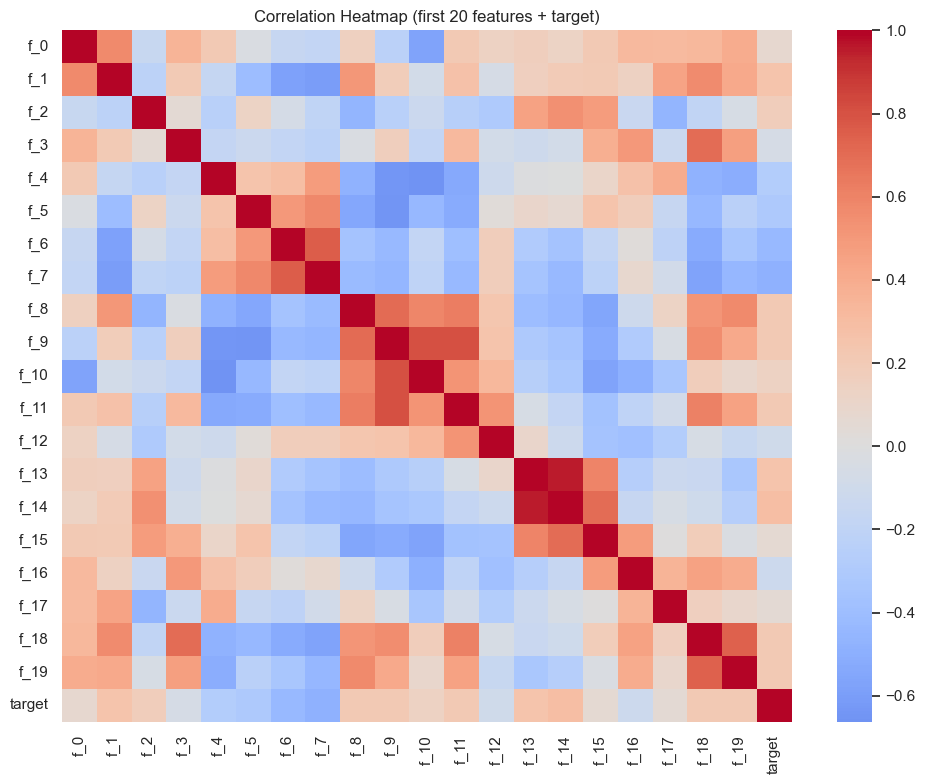

In [5]:
# Pearson correlations between each feature and the target

corr_with_target = df.corr()["target"].sort_values(ascending=False)
print("Top 20 features most positively correlated with target:")
display(corr_with_target.head(20))

print(" Top 20 features most negatively correlated with target:")
display(corr_with_target.tail(20))

subset_feats = [f"f_{i}" for i in range(min(20, n_features_for_df))] + ["target"]
corr_matrix = df[subset_feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (first 20 features + target)")
plt.tight_layout()
plt.show()


In [6]:
# PCA Analysis

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=20)
x_pca = pca.fit_transform(x_scaled)

print("Explained variance ratio (first 10 components):")
print(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance (first 10):")
print(np.cumsum(pca.explained_variance_ratio_[:10]))

max_points = 3000
idx = np.random.choice(len(x_pca), size=min(max_points, len(x_pca)), replace=False)

plt.figure(figsize=(7, 6))
sc = plt.scatter(x_pca[idx, 0], x_pca[idx, 1], c=y[idx], s=15, alpha=0.8)
plt.colorbar(sc, label="Target")
plt.title("PCA (2D) projection colored by target")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Explained variance ratio (first 10 components):
[0.42112882 0.15087926 0.0935849  0.07948883 0.05593943 0.02654025
 0.01056021 0.00811069 0.0062813  0.00569524]
Cumulative explained variance (first 10):
[0.42112882 0.57200808 0.66559298 0.74508181 0.80102124 0.82756149
 0.8381217  0.84623239 0.85251369 0.85820893]


IndexError: index 5955248 is out of bounds for axis 0 with size 5940001

<Figure size 700x600 with 0 Axes>